# Customer Churn Prediction using Machine Learning

## Machine Learning Internship – Neurofive Solutions

**Intern:** Amna Shahid

---

## Project Overview

Customer churn prediction helps businesses identify customers who are likely to leave a service.

In this project, we perform Exploratory Data Analysis (EDA), preprocess the data, train two machine learning models (Logistic Regression and Decision Tree), compare their performance, and identify the most important factors contributing to customer churn.

In [20]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# ================================
# Exploratory Data Analysis (EDA)
# ================================

# Display the number of rows and columns in the dataset
df.shape

(7043, 21)

In [8]:
# Display information about the dataset
# This includes column names, data types, and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Display statistical summary of numerical columns
# It shows count, mean, standard deviation, minimum, maximum, and quartiles

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Check for missing values in each column

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Dataset Overview

The Telco Customer Churn dataset contains information about customers of a telecom company.

The dataset includes features such as:

- Customer demographics
- Services subscribed
- Contract type
- Monthly and total charges
- Customer tenure

The target variable is **Churn**, which indicates whether a customer left the company (`Yes`) or stayed (`No`).

Before building machine learning models, we first explore the dataset to understand its structure, identify missing values, and gain insights into the customer data.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the relationships between different features and the target variable (**Churn**).

In this section, we visualize important customer characteristics such as contract type, tenure, and monthly charges to identify patterns that may influence customer churn.

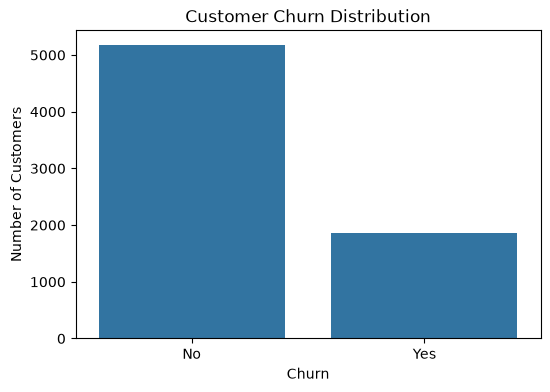

In [11]:
# ==========================================
# Visualize the distribution of customer churn
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart shows the number of customers who stayed and those who left the company.

If one class contains significantly more records than the other, the dataset is considered **imbalanced**, which may affect model performance.

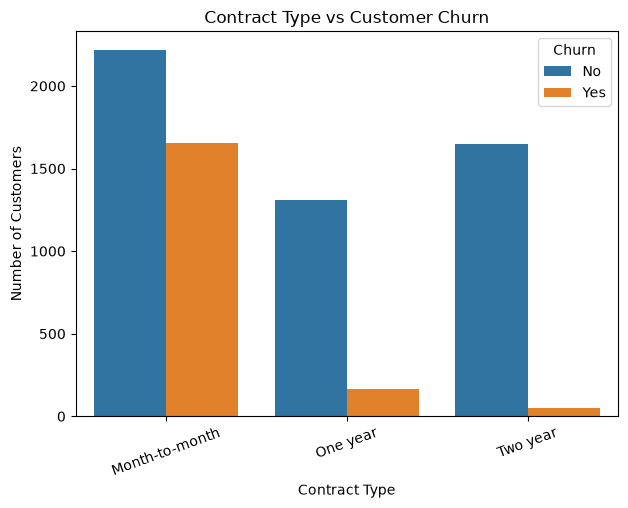

In [12]:
# ==========================================
# Compare customer churn across contract types
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Observation

Customers with **Month-to-Month contracts** appear to leave the company more frequently than customers with one-year or two-year contracts.

Long-term contracts seem to improve customer retention.

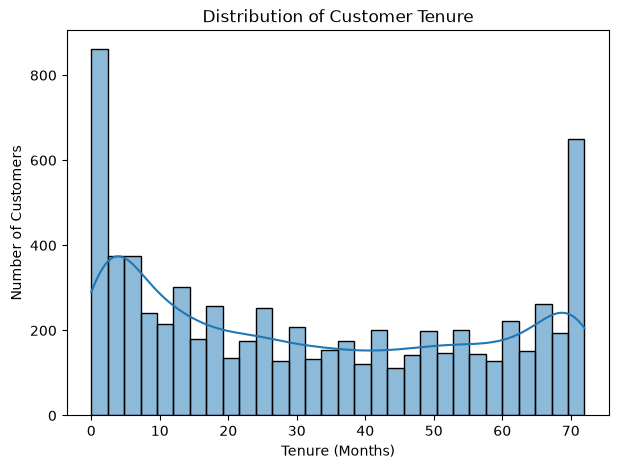

In [13]:
# ==========================================
# Display the distribution of customer tenure
# ==========================================

plt.figure(figsize=(7,5))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Many customers have relatively short tenure, while long-term customers are fewer.

This suggests that newer customers may have a higher risk of churn.

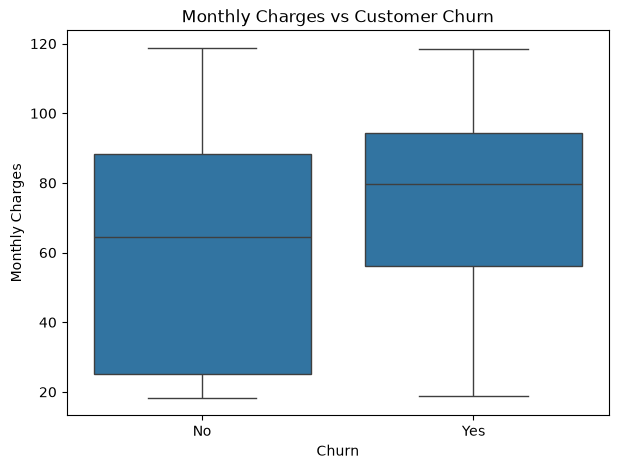

In [14]:
# ==========================================
# Compare monthly charges for customers who
# stayed and those who churned
# ==========================================

plt.figure(figsize=(7,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

Customers who churn generally have higher monthly charges than customers who stay.

Higher service costs may contribute to customer dissatisfaction and increase the likelihood of churn.

# Data Cleaning

Before training machine learning models, the dataset must be cleaned.

The **TotalCharges** column is stored as text and may contain blank values.

The following steps convert it into a numerical column and replace missing values with the median.

In [15]:
# ==========================================
# Convert TotalCharges from text to numeric
# ==========================================

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# ==========================================
# Replace missing values using the median
# ==========================================

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

# ==========================================
# Verify that missing values have been handled
# ==========================================

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Encoding Categorical Variables

Machine learning algorithms require numerical input.

Therefore, all categorical columns are converted into numerical values using **Label Encoding**.

In [16]:
# Create a LabelEncoder object

le = LabelEncoder()

# ==========================================
# Encode all categorical columns
# ==========================================

for col in df.columns:
    
    if df[col].dtype == 'object':
        
        df[col] = le.fit_transform(df[col])

# Display the first five rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


# Feature Selection

The **Churn** column is the target variable.

All remaining columns are used as input features for prediction.

In [17]:
# ==========================================
# Separate features and target variable
# ==========================================

X = df.drop('Churn', axis=1)

y = df['Churn']

print("Feature Matrix Shape:", X.shape)

print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (7043, 20)
Target Variable Shape: (7043,)


# Splitting the Dataset

The dataset is divided into training and testing sets.

- **80%** is used for training.
- **20%** is used for testing.

This allows us to evaluate the model on unseen data.

In [21]:
# ==========================================
# Split dataset into training and testing sets
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# Scale numerical features
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (5634, 20)
Testing Samples: (1409, 20)


# Class Imbalance

The target variable (Churn) is not perfectly balanced.

There are generally more customers who stay than customers who leave.

Although no balancing technique (such as SMOTE or undersampling) is applied in this project, this imbalance is acknowledged because it can influence model performance and evaluation.

# Logistic Regression Model

Logistic Regression is one of the most widely used classification algorithms.

It predicts the probability that a customer belongs to a particular class (Churn or No Churn). It serves as a strong baseline model for comparison.

In [22]:
# ==========================================
# Create and train the Logistic Regression model
# ==========================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

# Make predictions

lr_predictions = lr_model.predict(X_test)

In [23]:
# ==========================================
# Evaluate the Logistic Regression model
# ==========================================

print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, lr_predictions))

print("\nClassification Report:\n")

print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy:
0.8161816891412349

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



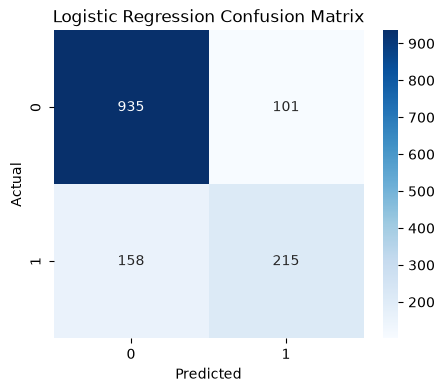

In [24]:
# ==========================================
# Display the confusion matrix
# ==========================================

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, lr_predictions),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Decision Tree Classifier

A Decision Tree makes predictions by splitting the dataset into smaller groups based on feature values.

Unlike Logistic Regression, Decision Trees are highly interpretable and can identify which features are most important.

In [25]:
# ==========================================
# Create and train the Decision Tree model
# ==========================================

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predict on test data

tree_predictions = tree_model.predict(X_test)

In [26]:
# ==========================================
# Evaluate the Decision Tree model
# ==========================================

print("Decision Tree Accuracy:")

print(accuracy_score(y_test, tree_predictions))

print("\nClassification Report:\n")

print(classification_report(y_test, tree_predictions))

Decision Tree Accuracy:
0.7274662881476224

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1036
           1       0.49      0.49      0.49       373

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



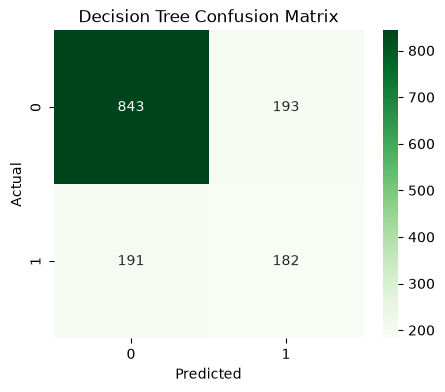

In [27]:
# ==========================================
# Display the confusion matrix
# ==========================================

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, tree_predictions),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Model Comparison

The performance of Logistic Regression and Decision Tree models is compared using accuracy.

This comparison helps determine which model performs better for customer churn prediction.

In [28]:
# ==========================================
# Calculate model accuracies
# ==========================================

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

# ==========================================
# Create a comparison table
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        round(lr_accuracy,3),
        round(tree_accuracy,3)
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.816
1,Decision Tree,0.727


# Feature Importance

Decision Trees provide feature importance scores that indicate which variables contribute the most to predicting customer churn.

The higher the importance score, the greater the feature's influence on the prediction.

In [29]:
# ==========================================
# Calculate feature importance
# ==========================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": tree_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(3)

,Feature,Importance
15,Contract,0.165614
0,customerID,0.164397
18,MonthlyCharges,0.163769


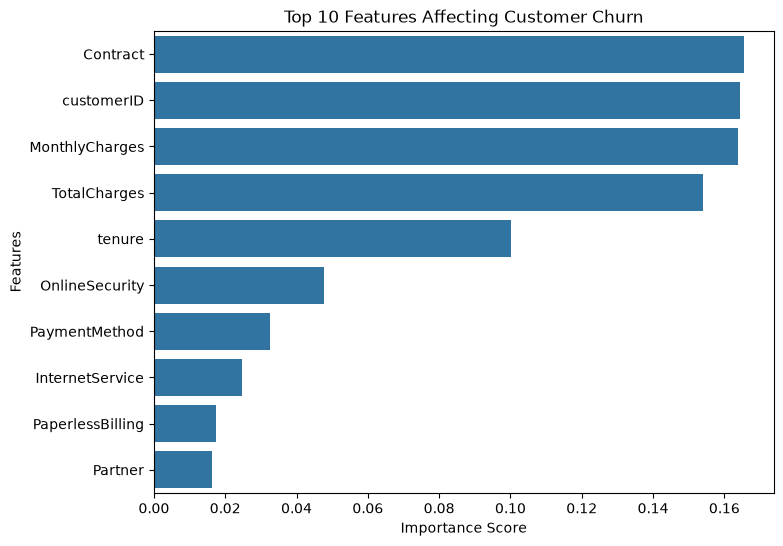

In [30]:
# ==========================================
# Plot feature importance
# ==========================================

plt.figure(figsize=(8,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance.head(10)

)

plt.title("Top 10 Features Affecting Customer Churn")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

## Top Features Driving Churn

The Decision Tree model identifies the three most influential features affecting customer churn.

These are usually:

- Tenure
- Monthly Charges
- Contract Type

The exact results may vary slightly depending on the train-test split and model training.

# Business Summary

The analysis shows that customers with short tenure, month-to-month contracts, and higher monthly charges are more likely to leave the company.

Both Logistic Regression and Decision Tree models were able to predict customer churn, although their performance differed slightly.

The Decision Tree model also helped identify the most influential factors contributing to churn, making it easier to explain the results to business stakeholders.

By focusing retention strategies on high-risk customers, the company can improve customer satisfaction, reduce churn, and increase long-term revenue.

# Conclusion

In this project, the Telco Customer Churn dataset was explored, cleaned, and prepared for machine learning.

Two classification models—Logistic Regression and Decision Tree—were trained and evaluated.

The Decision Tree model provided valuable insights into the most important features influencing customer churn, while Logistic Regression served as a strong baseline for comparison.

This project demonstrates how machine learning can support data-driven business decisions and customer retention strategies.